In [1]:
import glob

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import xarray as xr
import xcdat as xc
import cmocean
import geopandas as gpd
import regionmask

Matplotlib is building the font cache; this may take a moment.


## Mask

In [2]:
aus_shape = gpd.read_file(
    '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp',
    crs="epsg:4326"
)

def clip_data(da):
    """Clip data"""

    region = regionmask.from_geopandas(
        aus_shape,
        names='AUS_NAME21',
        abbrevs='AUS_CODE21',
        name='country',
    )
    mask = region.mask_3D(da)
    mask = mask.isel(region=(mask.abbrevs=='AUS'))
    mask = mask.squeeze()
    da_clipped = da.where(mask)
    
    return da_clipped

/g/data/xv83/dbi599/miniconda3/envs/npcp4/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option CRS
  return ogr_read(


In [3]:
fraction_dir = '/g/data/ia39/npcp/data/pr/observations/AGCD/raw/task-reference/'
fraction_file = 'pr-weights_r005_AGCD_v1-0-1_day_19600101-20221231.nc'
ds_fraction = xr.open_dataset(fraction_dir+fraction_file)
da_fraction = ds_fraction['fraction']
    
def mask_by_pr_ob_fraction(da, threshold=0.9):
    """Mask data according to precip obs fraction"""
    
    da_selection = da_fraction > threshold 
    da = da.where(da_selection)
    da = clip_data(da)
    
    return da

In [4]:
clim_dict = {}

## AGCD

In [5]:
agcd_files = sorted(glob.glob('/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_*_daily.nc'))

In [6]:
ds_agcd = xr.open_mfdataset(agcd_files[60:-2])

/jobfs/165906052.gadi-pbs/ipykernel_4067866/4263086412.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_agcd = xr.open_mfdataset(agcd_files[60:-2])


In [7]:
da_agcd_annual = ds_agcd['precip'].resample(time='YE').sum('time', skipna=True, keep_attrs=True)
da_agcd_annual = da_agcd_annual.compute()

In [8]:
da_agcd_clim = da_agcd_annual.mean(dim='time').compute()

In [9]:
clim_dict['AGCD'] = mask_by_pr_ob_fraction(da_agcd_clim)

## Model data

In [10]:
infiles = {}

In [11]:
infiles['QME'] = [
    '/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/bias-adjusted-output/AUST-05i/BOM/ACCESS-CM2/historical/r4i1p1f1/BARPA-R/v1-r1-ACS-QME-AGCDv1-1960-2022/yr/prAdjust/v20241216/prAdjust_AUST-05i_ACCESS-CM2_historical_r4i1p1f1_BOM_BARPA-R_v1-r1-ACS-QME-AGCDv1-1960-2022_yr_1960-2014.nc',
    '/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/bias-adjusted-output/AUST-05i/BOM/ACCESS-CM2/ssp370/r4i1p1f1/BARPA-R/v1-r1-ACS-QME-AGCDv1-1960-2022/yr/prAdjust/v20241216/prAdjust_AUST-05i_ACCESS-CM2_ssp370_r4i1p1f1_BOM_BARPA-R_v1-r1-ACS-QME-AGCDv1-1960-2022_yr_2015-2100.nc',
]
infiles['MRNBC'] = [
    '/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/bias-adjusted-output/AUST-05i/BOM/ACCESS-CM2/historical/r4i1p1f1/BARPA-R/v1-r1-ACS-MRNBC-AGCDv1-1960-2022/yr/prAdjust/v20241216/prAdjust_AUST-05i_ACCESS-CM2_historical_r4i1p1f1_BOM_BARPA-R_v1-r1-ACS-MRNBC-AGCDv1-1960-2022_yr_1960-2014.nc',
    '/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/bias-adjusted-output/AUST-05i/BOM/ACCESS-CM2/ssp370/r4i1p1f1/BARPA-R/v1-r1-ACS-MRNBC-AGCDv1-1960-2022/yr/prAdjust/v20241216/prAdjust_AUST-05i_ACCESS-CM2_ssp370_r4i1p1f1_BOM_BARPA-R_v1-r1-ACS-MRNBC-AGCDv1-1960-2022_yr_2015-2100.nc',
]
infiles['raw'] = [
    '/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/DD/AUST-05i/BOM/ACCESS-CM2/historical/r4i1p1f1/BARPA-R/v1-r1/yr/pr/v20241216/pr_AUST-05i_ACCESS-CM2_historical_r4i1p1f1_BOM_BARPA-R_v1-r1_yr_1960-2014.nc',
    '/g/data/ia39/australian-climate-service/test-data/CORDEX/output-CMIP6/DD/AUST-05i/BOM/ACCESS-CM2/ssp370/r4i1p1f1/BARPA-R/v1-r1/yr/pr/v20241216/pr_AUST-05i_ACCESS-CM2_ssp370_r4i1p1f1_BOM_BARPA-R_v1-r1_yr_2015-2100.nc',
]

In [12]:
def climatology(file_list, var):
    """Calculate the 1960-2022 climatology."""

    ds = xr.open_mfdataset(file_list)
    da_clim = ds[var].sel(time=slice('1960-01-01', '2022-12-31')).mean(dim='time').compute()
    da_clim = mask_by_pr_ob_fraction(da_clim)

    return da_clim

In [13]:
clim_dict['QME'] = climatology(infiles['QME'], 'prAdjust')

In [14]:
clim_dict['MRNBC'] = climatology(infiles['MRNBC'], 'prAdjust')

In [15]:
clim_dict['raw'] = climatology(infiles['raw'], 'pr')

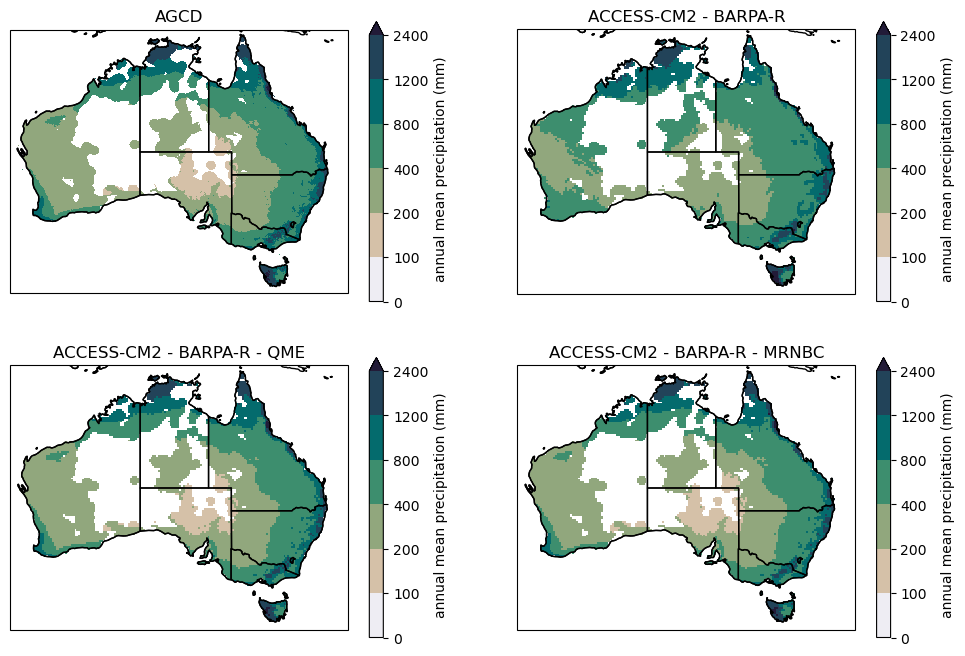

In [20]:
fig = plt.figure(figsize=[12, 8])

levels_clim = [0, 100, 200, 400, 800, 1200, 2400]

ax1 = fig.add_subplot(221, projection=ccrs.PlateCarree())
im1 = clim_dict['AGCD'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_title('AGCD')

ax2 = fig.add_subplot(222, projection=ccrs.PlateCarree())
im2 = clim_dict['raw'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
ax2.set_title('ACCESS-CM2 - BARPA-R')

ax3 = fig.add_subplot(223, projection=ccrs.PlateCarree())
im3 = clim_dict['QME'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
ax3.set_title('ACCESS-CM2 - BARPA-R - QME')

ax4 = fig.add_subplot(224, projection=ccrs.PlateCarree())
im4 = clim_dict['MRNBC'].plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.rain,
    levels=levels_clim,
    cbar_kwargs={'label': 'annual mean precipitation (mm)'},
    extend='max',
)
ax4.coastlines()
ax4.add_feature(cartopy.feature.STATES)
ax4.set_title('ACCESS-CM2 - BARPA-R - MRNBC')

plt.show()

In [26]:
diff_dict = {}
diff_dict_pct = {}

def calc_diff(model_data):
    """Calculate difference between model and obs"""

    diff_raw = model_data - clim_dict['AGCD']
    diff_pct = (diff_raw / clim_dict['AGCD']) * 100

    return diff_raw, diff_pct

In [27]:
diff_dict['raw'], diff_dict_pct['raw'] = calc_diff(clim_dict['raw'])

In [28]:
diff_dict['QME'], diff_dict_pct['QME'] = calc_diff(clim_dict['QME'])

In [29]:
diff_dict['MRNBC'], diff_dict_pct['MRNBC'] = calc_diff(clim_dict['MRNBC'])

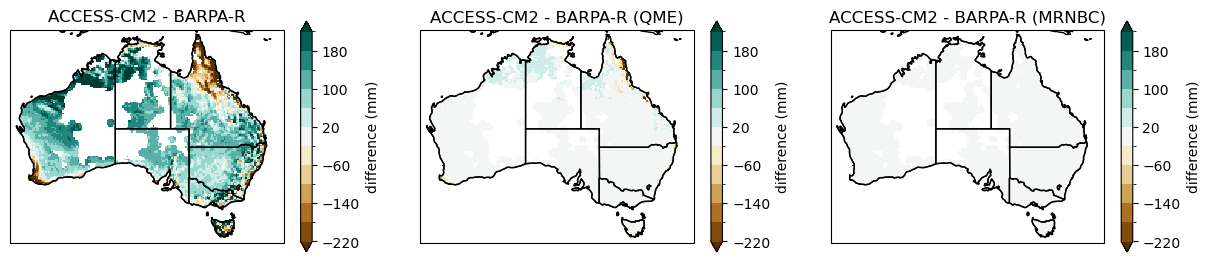

In [40]:
levels_diff = [-220, -180, -140, -100, -60, -20, 20 , 60, 100, 140, 180, 220]

fig = plt.figure(figsize=[15,3])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = diff_dict['raw'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_diff,
    cbar_kwargs={'label': 'difference (mm)'},
    extend='both',
)
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_title('ACCESS-CM2 - BARPA-R')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = diff_dict['QME'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_diff,
    cbar_kwargs={'label': 'difference (mm)'},
    extend='both',
)
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
ax2.set_title('ACCESS-CM2 - BARPA-R (QME)')

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff_dict['MRNBC'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_diff,
    cbar_kwargs={'label': 'difference (mm)'},
    extend='both',
)
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
ax3.set_title('ACCESS-CM2 - BARPA-R (MRNBC)')

plt.show()

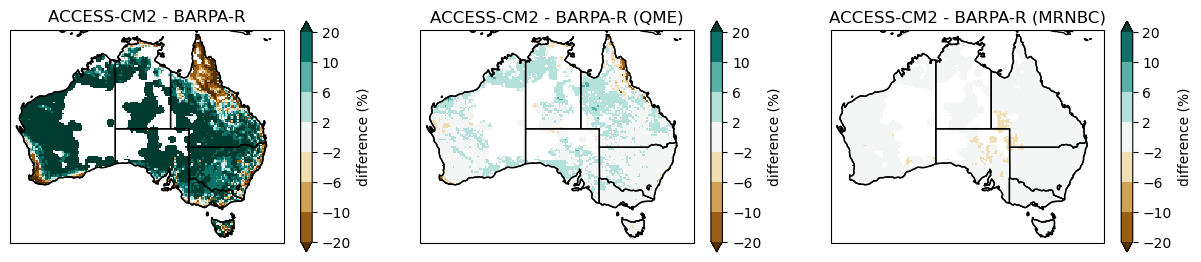

In [41]:
levels_pct = [-20, -10, -6, -2, 2, 6, 10, 20]

fig = plt.figure(figsize=[15,3])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = diff_dict_pct['raw'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_pct,
    cbar_kwargs={'label': 'difference (%)'},
    extend='both',
)
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.set_title('ACCESS-CM2 - BARPA-R')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = diff_dict_pct['QME'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_pct,
    cbar_kwargs={'label': 'difference (%)'},
    extend='both',
)
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
ax2.set_title('ACCESS-CM2 - BARPA-R (QME)')

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff_dict_pct['MRNBC'].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_pct,
    cbar_kwargs={'label': 'difference (%)'},
    extend='both',
)
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
ax3.set_title('ACCESS-CM2 - BARPA-R (MRNBC)')

plt.show()